In [1]:
"""Nonlinear and linear car simulation sample code.

MECH 412
J R Forbes, 2025/09/04
Modified by:
Aidan Kimberley, 2025/09/15

Car model from Ch 2.3.3 of Guzzella with some modifications from Frazzoli.
See Guzzella Sciarretta "Vehicle Propulsion Systems" and
Guzzella Onder "Introduction to Modeling and Control of Internal Combustion
Engine Systems"
"""
# %%
# Import packages
import numpy as np
import control
from scipy import signal
from scipy import integrate
from scipy import constants as cst  # https://docs.scipy.org/doc/scipy/reference/constants.html
from matplotlib import pyplot as plt

In [2]:
# %%

# Functions and classes

# @@@@@@@@@@@@ Do no modify START @@@@@@@@@@@@
# This is an object, also called a class. We need this object to numerically
# integrate the nonlinear ODE.
class CarClass:
    def __init__(self, m, J, gamma, r_w, CaA, c_r):
        """Constructor car object

        Parameters
        ----------
        m : float
            Mass, kg
        J : float
            Rotational inertia, kg * m ** 2
        gamma : float
            Gear ratio, unitless
        r_w : float
            Wheel radius, m
        CaA : float
            Aero drag coefficient times frontal area, m ** 2
        c_r : float
            Rolling friction coefficient, unitless        
        """
        self.m = m
        self.J = J
        self.gamma = gamma
        self.r_w = r_w
        self.CaA = CaA
        self.c_r = c_r

    @property
    def _M(self):
        return self.m + self.J / (self.gamma * self.r_w) ** 2  # effective mass

    def ode(self, t, y, rho, alpha):
        """Method for integration of ODE.

        y_dot = f(y) given y0

        Parameters
        ----------
        t : float
            Time, seconds,
        y : numpy.ndarray
            Input, units, (2, 1)

        Returns
        -------
        numpy.ndarray :
            y_dot, units, shape = (2, 1)
        """
        # Extract position and velocity
        q = y[0]
        v = y[1]

        delta_u = input(t)
        u_bar = self.gamma * self.r_w * self.m * cst.g * (self.c_r + np.sin(alpha))
        u = u_bar + delta_u  # input

        y_dot = np.array([[v],
                          [1 / self._M * (u / self.gamma / self.r_w - rho * self.CaA * v ** 2 / 2 - self.m * cst.g * (self.c_r + np.sin(alpha)))]])

        return y_dot.ravel()  # flatten the array y_dot


# This is the input torque function.
def input(t):
    u_max = 500  # N * m
    u = u_max * signal.sawtooth(2 * np.pi / 10 * t + np.pi / 2, width=0.5)
    return u

In [3]:
# %%

# Numerically integrate ODE
# Time
dt = 1e-3
t_start = 0
t_end = 30
t = np.arange(t_start, t_end, dt)

# Car properties
m = 1500  # kg, Guzzella Sciarretta Ch 2.2.3
J = 0.2  # kg / m ** 2, engine inertia, Guzzella Onder pg 80
gamma = 1 / 14  # gear ratio, Guzzella Sciarretta pg 65
r_w = 0.3  # m, Guzzella Sciarretta pg 65
CaA = 0.7  # m ** 2, aero drag coefficent time frontal area, Guzzella Sciarretta Ch 2.2.3
c_r = 0.013  # rolling friction, Guzzella Sciarretta Ch 2.2.3

# Surrounding environment properties
rho = 1.225  # kg / m ** 3, air density
alpha = 15 / 180 * np.pi  # grade of road

# Initiate CarClass instance
car = CarClass(m, J, gamma, r_w, CaA, c_r)

# ICs
q0 = 0  # m
v0 = 0  # m / s

# Find time-domain response by integrating the ODE using Runge-Kutta 4-5
y0 = np.array([q0, v0])  # initial condition
sol = integrate.solve_ivp(
    car.ode,
    (t_start, t_end),
    y0,
    args=(rho, alpha),  # optional arguments, in this case, the environment properties
    t_eval=t,
    rtol=1e-6,
    atol=1e-6,
    method='RK45',
)

In [4]:
# %%

# Extract states
q = sol.y[0, :]  # position, the nonlinear response output, "q_{nonlinear}"
v = sol.y[1, :]  # velocity
N = q.size

# Input applied
u_bar = gamma * r_w * m * cst.g * (c_r + np.sin(alpha))
delta_u = input(t)
u = u_bar + delta_u

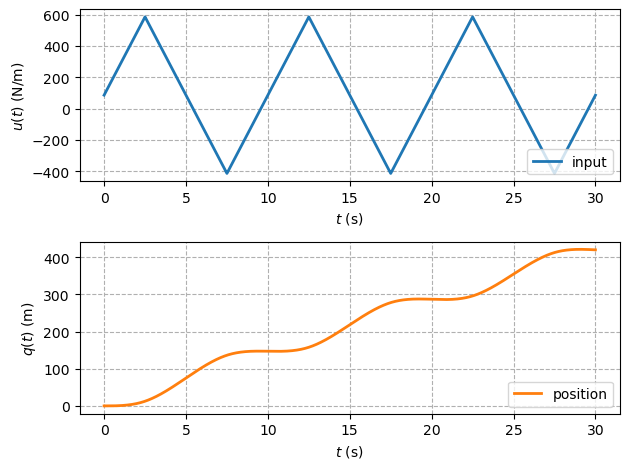

In [5]:
# %%

# Plotting
# Plotting parameters
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif', size=14)
plt.rc('lines', linewidth=2)
plt.rc('axes', grid=True)
plt.rc('grid', linestyle='--')

# Plot input and position versus time
fig, ax = plt.subplots(2, 1)
# Format axes
for a in np.ravel(ax):
    a.set_xlabel(r'$t$ (s)')
ax[0].set_ylabel(r'$u(t)$ (N/m)')
ax[1].set_ylabel(r'$q(t)$ (m)')
# Plot data
ax[0].plot(t, u, label='input')
ax[1].plot(t, q, label='position', color='C1')
for a in np.ravel(ax):
    a.legend(loc='lower right')
fig.tight_layout()
# fig.savefig('blank.pdf')

# @@@@@@@@@@@@ Do no modify END @@@@@@@@@@@@
# Below this line is where you modify the code.

In [6]:
# %%

# Linearized system definition and simulation

# EP position
q_bar = 0

# Create transfer function


C1 = car._M * car.gamma * car.r_w
C2 = (rho * car.CaA * 0)/car._M # REPLACE 0 WITH x2_bar

P = control.tf([1],[C1,C2,0])

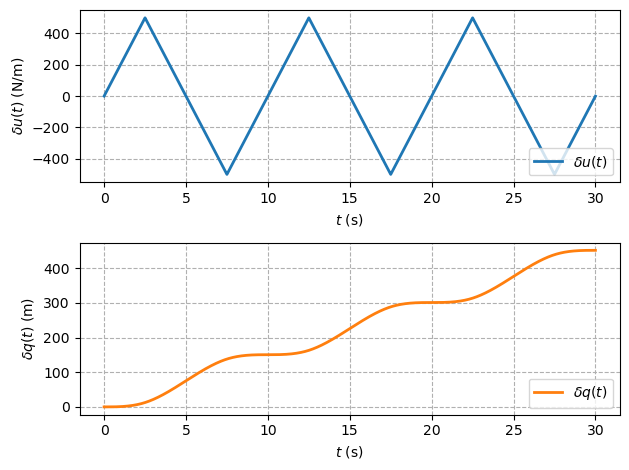

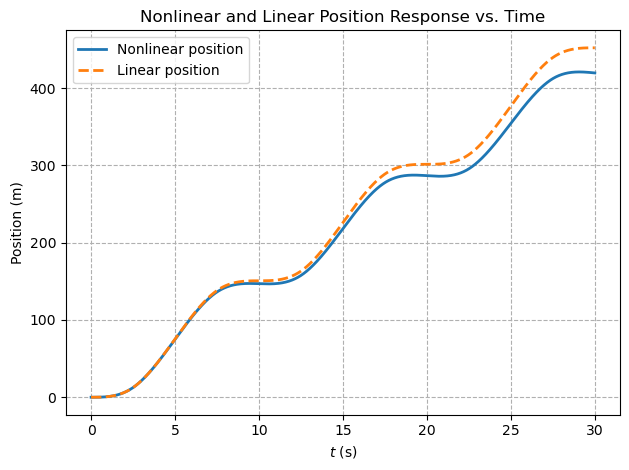

In [7]:
#%%

# Forced response
t_delta_q, delta_q = control.forced_response(P, t, delta_u)
q_bar_plus_delta_q = q_bar + delta_q  # this is the linear response output, "q_{linear}"

# Plot input and position versus time
fig, ax = plt.subplots(2, 1)
# Format axes
for a in np.ravel(ax):
    a.set_xlabel(r'$t$ (s)')
ax[0].set_ylabel(r'$\delta u(t)$ (N/m)')
ax[1].set_ylabel(r'$\delta q(t)$ (m)')
# Plot data
ax[0].plot(t, delta_u, label=r'$\delta u(t)$')
ax[1].plot(t, delta_q, label=r'$\delta q(t)$', color='C1')
for a in np.ravel(ax):
    a.legend(loc='lower right')
fig.tight_layout()
# fig.savefig('blank.pdf')

# Plot linear and nonlinear response
fig, ax = plt.subplots()
# Format axes
ax.set_title(r'Nonlinear and Linear Position Response vs. Time')
ax.set_xlabel(r'$t$ (s)')
ax.set_ylabel(r'Position (m)')
# Plot data
ax.plot(t, q, label='Nonlinear position', color='C0')
ax.plot(t, q_bar_plus_delta_q , '--', label='Linear position', color='C1')
ax.legend(loc='upper left')
fig.tight_layout()
# fig.savefig('blank.pdf')

QUESTION G)IV) The linear approximation and nonlinear lines start together but start to diverage as t increases. They start to get noticable different around 10 seconds and continue to diverage beyond that.

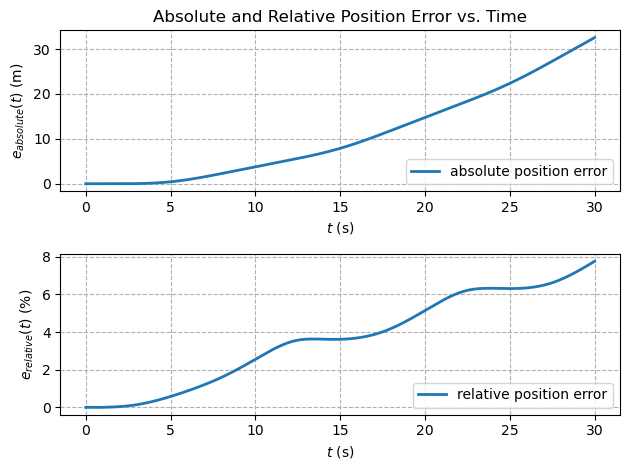

In [14]:
# %%

# Error
e_q = q - q_bar_plus_delta_q  # absolute position error (but not absolute value)

e_q_rel = np.zeros_like(e_q)
with np.errstate(divide='ignore', invalid='ignore'):
    mask = np.abs(q) > 1e-12
    e_q_rel[mask] = e_q[mask] / q[mask]
    # e_q_rel[~mask] remains zero


eps_q = 1e-3
for i in range(q.size):
    e_q[i] = np.abs(e_q[i])  # absolute value of position absolute error
    if (np.abs(q[i]) > eps_q):
        e_q_rel[i] = e_q[i] / np.abs(q[i]) * 100 # relative velocity error
    else:
        e_q_rel[i] = 0

fig, ax = plt.subplots(2, 1)
# Format axes
ax[0].set_title(r'Absolute and Relative Position Error vs. Time')
for a in np.ravel(ax):
    a.set_xlabel(r'$t$ (s)')
ax[0].set_ylabel(r'$e_{absolute}(t)$ (m)')
ax[1].set_ylabel(r'$e_{relative}(t)$ (%)')
# Plot data
ax[0].plot(t, e_q, label='absolute position error', color='C0')
ax[1].plot(t, e_q_rel, label='relative position error', color='C0')
ax[0].legend(loc='lower right')
ax[1].legend(loc='lower right')
fig.tight_layout()
# fig.savefig('blank.pdf')

QUESTION G)V) The error starts 0 around the equilibtium point but ther error grows over time. Around 4 seconds you can see it start to diverage but presumably they are only exactly equal at the equilibrium point.

QUESTION H)The linearized system is a reasonable approximation for about 5 seconds, and then it fails to give accurate approximations.

In [15]:
# %%

# Plot show
plt.show()